# ⚽ LaLiga Team Style Scoring
## Feature Engineering untuk K-Means Clustering

---

### 📋 Deskripsi Notebook

Notebook ini merupakan bagian dari penelitian skripsi **Data Engineering** yang menganalisis gaya bermain klub-klub La Liga.

**Tujuan:**
- Membangun **10 Style Scores** yang merepresentasikan dimensi taktis gaya bermain setiap tim.
- Setiap score dihitung menggunakan **weighted average** dari indikator-indikator statistik yang telah dinormalisasi.
- Hasil akhir berupa dataset `teams_style_scores.csv` yang siap digunakan pada notebook K-Means Clustering berikutnya.

**Input:**
- Tabel `gold.teams_statistics` dari PostgreSQL — One Big Table (OBT) hasil proses ETL dari Bronze → Silver → Gold.
- Data sudah bersih dan berada pada Gold Layer, sehingga **tidak dilakukan preprocessing tambahan**.

**Output:**
- DataFrame `teams_style_scores` berisi **club + 10 style scores** (skala 0–100).
- File `data/ml_ready/teams_style_scores.csv`.

---

### 📊 10 Dimensi Style Scoring

| No | Style Score | Tujuan | Interpretasi Skor Tinggi |
|----|------------|--------|-------------------------|
| 1 | **Possession Score** | Mengukur dominasi penguasaan bola dan kemampuan mengontrol tempo | Tim sangat dominan menguasai bola dan mengontrol ritme permainan |
| 2 | **Build-up Score** | Mengukur kemampuan membangun serangan secara bertahap | Tim membangun serangan secara sabar dan terstruktur |
| 3 | **Chance Creation Score** | Mengukur kemampuan tim menciptakan peluang mencetak gol | Tim mampu menghasilkan banyak peluang berkualitas |
| 4 | **Attacking Efficiency Score** | Mengukur efektivitas tim dalam mengonversi peluang menjadi gol | Tim sangat efisien dalam penyelesaian akhir |
| 5 | **Direct Play Score** | Mengukur kecenderungan tim bermain cepat dan vertikal | Tim bermain langsung, cepat, dan vertikal |
| 6 | **Counter Attack Score** | Mengukur efektivitas serangan balik setelah merebut bola | Tim sangat berbahaya saat transisi menyerang |
| 7 | **Pressing Intensity Score** | Mengukur intensitas dan efektivitas tekanan terhadap lawan | Tim melakukan high pressing secara agresif |
| 8 | **Defensive Solidity Score** | Mengukur kualitas pertahanan dalam membatasi peluang lawan | Tim memiliki pertahanan yang sangat kokoh |
| 9 | **Set Piece Threat Score** | Mengukur ancaman tim melalui situasi bola mati | Tim sangat berbahaya dari sepak pojok dan tendangan bebas |
| 10 | **Discipline Score** | Mengukur tingkat kedisiplinan dan minimnya kesalahan | Tim bermain disiplin dan minim kesalahan |

---

### ⚖️ Metode Perhitungan

1. **Normalisasi:** Seluruh indikator dinormalisasi menggunakan **Min-Max Scaling** ke rentang 0–100.
2. **Inverse Scaling:** Indikator yang memiliki arti "semakin kecil semakin baik" (misal: gol kebobolan, pelanggaran) di-inverse terlebih dahulu agar interpretasi konsisten — **skor tinggi selalu berarti performa kuat**.
3. **Weighted Average:**
   - **Primary Indicators = 70%** (bobot dibagi rata antar indikator primary)
   - **Supporting Indicators = 30%** (bobot dibagi rata antar indikator supporting)

> ⚠️ **Catatan:** Notebook ini **TIDAK** melakukan clustering. Output notebook ini menjadi input untuk notebook K-Means Clustering berikutnya.

---

## 1. Import Library

In [298]:
# === Standard Library ===
import os
import warnings
from pathlib import Path

# === Data Manipulation ===
import numpy as np
import pandas as pd

# === Visualization ===
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# === Database ===
from sqlalchemy import create_engine
from dotenv import load_dotenv

# === Preprocessing & Dimensionality Reduction ===
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# === Settings ===
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Semua library berhasil diimpor.")

✅ Semua library berhasil diimpor.


---

## 2. Load Data dari PostgreSQL

Data dimuat langsung dari tabel **`gold.teams_statistics`** yang merupakan *One Big Table (OBT)* hasil proses ETL.  
Tabel ini menggabungkan 12 sub-tabel statistik tim LaLiga menjadi satu tabel dengan 124+ kolom.

Koneksi menggunakan **SQLAlchemy** dengan credential dari file `.env`.

In [299]:
# # --- Konfigurasi Database ---
# PROJECT_ROOT = Path.cwd().parent
# load_dotenv(PROJECT_ROOT / ".env")

# DB_URL = (
#     f"postgresql://{os.getenv('DB_USER', 'g')}:{os.getenv('DB_PASSWORD', '')}"
#     f"@{os.getenv('DB_HOST', 'localhost')}:{os.getenv('DB_PORT', '5432')}"
#     f"/{os.getenv('DB_NAME', 'laliga')}"
# )

# engine = create_engine(DB_URL)
# print(f"✅ Engine created: {engine.url.database}@{engine.url.host}")

In [300]:
# --- Load Gold OBT ---
# query = "SELECT * FROM gold.teams_statistics ORDER BY club"
# df = pd.read_sql(query, engine)

PROJECT_ROOT = Path.cwd().parent
data_path = PROJECT_ROOT / "data" / "gold" / "teams" / "teams_ml_features.csv"

df = pd.read_csv(data_path)

print(f"✅ Data berhasil dimuat.")
print(f"   Shape : {df.shape[0]} tim × {df.shape[1]} kolom")
print(f"   Clubs : {df['club'].nunique()} tim unik")

✅ Data berhasil dimuat.
   Shape : 20 tim × 61 kolom
   Clubs : 20 tim unik


---

## 3. Validasi Data Gold

Karena data sudah melalui proses ETL dan berada di **Gold Layer**, tahap ini hanya melakukan pengecekan sederhana sebagai konfirmasi bahwa data siap digunakan.

In [301]:
# --- Preview 5 baris pertama ---
df.head()

,club,att_goals,att_xg,att_goals_vs_xg,att_shots,att_sot,att_conversion_pct,att_xg_per_shot,att_goals_per_game,att_np_goals,att_np_xg,att_np_goals_vs_xg,att_sp_goals,att_sp_shots,att_sp_xg,att_sp_goal_pct,att_sp_shot_pct,att_sp_xg_pct,att_touches_in_box,att_hit_woodwork,att_fast_breaks_total,att_fast_breaks_goals,def_tackles,def_interceptions,def_possession_won,def_blocks,def_clearances,def_avg_possession_pct,def_goals_conceded,def_xg_against,def_goals_vs_xg_against,def_shots_against,def_shots_in_box_pct,pas_passes_total,pas_passes_successful,pas_passes_pct,pas_final_third_successful,pas_final_third_pct,pas_direction_fwd_pct,pas_crosses_successful,pas_through_balls,prs_ppda,prs_pressed_seqs,prs_start_distance,prs_high_turnovers_total,prs_high_turnovers_shot_ending,prs_high_turnovers_goal_ending,prs_high_turnovers_shot_pct,seq_passes_10_plus,seq_direct_speed,seq_passes_per_seq,seq_sequence_time,seq_buildups_total,seq_direct_attacks_total,seq_direct_attacks_goals,msc_fouls,msc_yellows,msc_reds,msc_errors_lead_to_shot,msc_errors_lead_to_goal,msc_pens_conceded
0,Alaves,44,47.05,-3.05,463,153,9.50,0.10,1.16,37,41.54,-4.54,11,135,11.00,25.00,29.16,23.37,778,12,29,1,691,297,1859,148,901,48.00,56,47.67,8.33,473,64.69,15362,12346,80.40,2915,67.70,34.80,117,32,11.50,416,41.40,233,44,4,18.88,299,1.81,3.14,8.01,56,47,1,539,86,5,19,4,5
1,Athletic Bilbao,43,50.60,-7.60,522,172,8.24,0.10,1.13,38,45.87,-7.87,6,139,10.55,13.95,26.63,20.85,978,12,18,4,571,349,1983,78,808,48.60,58,42.24,15.76,357,64.43,15562,12496,80.30,3421,66.90,35.00,137,59,11.20,557,45.00,368,61,3,16.58,276,2.03,3.08,8.12,57,42,5,497,73,7,27,6,6
2,Atlético Madrid,62,58.87,3.13,498,193,12.45,0.12,1.63,59,55.71,3.29,12,132,11.00,19.35,26.51,18.68,1060,15,33,8,647,297,1839,114,812,53.30,44,48.98,-4.98,441,61.45,19208,16443,85.60,4121,75.80,30.20,130,100,12.20,427,42.30,267,31,5,11.61,495,1.70,4.16,11.03,124,64,2,399,77,5,22,4,6
3,Barcelona,95,86.62,8.38,692,257,13.73,0.13,2.50,88,78.73,9.27,15,155,11.48,15.79,22.40,13.25,1340,31,37,11,618,280,1756,95,716,68.80,36,45.33,-9.33,346,77.75,24800,22316,90.00,5850,81.60,25.70,89,121,8.70,471,43.90,294,51,10,17.35,845,1.68,5.19,14.22,231,65,9,348,59,2,22,3,5
4,Celta Vigo,53,49.52,3.48,382,153,13.87,0.13,1.39,45,43.21,1.79,7,78,6.27,13.21,20.42,12.65,749,5,25,3,545,274,1710,130,914,50.50,48,49.70,-1.70,478,64.44,18909,16281,86.10,3727,74.90,29.00,61,121,13.90,350,39.50,214,33,5,15.42,528,1.60,4.38,11.65,110,53,4,425,71,1,34,8,11


In [302]:
# --- Informasi tipe data ---
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   club                            20 non-null     str    
 1   att_goals                       20 non-null     int64  
 2   att_xg                          20 non-null     float64
 3   att_goals_vs_xg                 20 non-null     float64
 4   att_shots                       20 non-null     int64  
 5   att_sot                         20 non-null     int64  
 6   att_conversion_pct              20 non-null     float64
 7   att_xg_per_shot                 20 non-null     float64
 8   att_goals_per_game              20 non-null     float64
 9   att_np_goals                    20 non-null     int64  
 10  att_np_xg                       20 non-null     float64
 11  att_np_goals_vs_xg              20 non-null     float64
 12  att_sp_goals                    20 non-null     i

In [303]:
# --- Statistik deskriptif ---
df.describe().T

,count,mean,std,min,25%,50%,75%,max
att_goals,20.00,51.20,15.97,26.00,43.00,46.50,59.00,95.00
att_xg,20.00,51.49,12.84,30.59,45.34,49.36,54.72,86.62
att_goals_vs_xg,20.00,-0.29,6.77,-12.19,-5.80,0.20,3.77,12.96
att_shots,20.00,474.30,86.12,352.00,422.00,459.00,504.00,692.00
att_sot,20.00,164.80,38.08,105.00,146.50,157.50,177.25,257.00
att_conversion_pct,20.00,10.71,2.24,6.91,9.16,10.38,12.07,15.82
att_xg_per_shot,20.00,0.11,0.01,0.09,0.10,0.10,0.12,0.13
att_goals_per_game,20.00,1.35,0.42,0.68,1.13,1.23,1.55,2.50
att_np_goals,20.00,46.00,14.68,24.00,38.00,41.50,52.25,88.00
att_np_xg,20.00,46.21,11.66,27.43,39.39,44.11,50.26,78.73


In [304]:
# --- Cek missing values ---
missing = df.isnull().sum()
missing_count = missing[missing > 0]

if missing_count.empty:
    print("✅ Tidak ada missing values. Data Gold siap digunakan.")
else:
    print("⚠️ Ditemukan missing values:")
    print(missing_count)

✅ Tidak ada missing values. Data Gold siap digunakan.


---

## 4. Definisi Style Scoring Configuration

Sebelum membangun fungsi-fungsi scoring, kita mendefinisikan terlebih dahulu **konfigurasi indikator** untuk setiap style.  
Konfigurasi ini menjadi *single source of truth* yang memastikan konsistensi antara definisi dan implementasi.

Setiap style memiliki:
- **Primary Indicators** — Indikator utama yang mendefinisikan inti dari style tersebut (bobot total: **70%**).
- **Supporting Indicators** — Indikator pelengkap yang menambah nuansa (bobot total: **30%**).
- **Inverse Indicators** — Indikator yang harus di-inverse karena nilai rendah = performa baik.

In [305]:
# ===========================================================================
# Style Scoring Configuration
# ===========================================================================
# Setiap key = nama style
# Setiap value = dict berisi:
#   'primary'  : list kolom primary indicators
#   'supporting': list kolom supporting indicators
#   'inverse'  : list kolom yang perlu di-inverse (rendah = baik)
#
# Bobot:
#   Primary   = 70% / jumlah_primary   (per indikator)
#   Supporting = 30% / jumlah_supporting (per indikator)
# ===========================================================================

# STYLE_CONFIG = {
#     # ----- 1. Possession Score -----
#     "possession": {
#         "primary": [
#             "def_avg_possession_pct",
#             "pas_passes_total",
#             "pas_passes_successful",
#             "pas_passes_pct",
#         ],
#         "supporting": [
#             "pas_final_third_pct",
#             "seq_passes_per_seq",
#             "seq_sequence_time",
#         ],
#         "inverse": [],
#     },

#     # ----- 2. Build-up Score -----
#     "build_up": {
#         "primary": [
#             "seq_buildups_total",
#             "seq_passes_per_seq",
#             "seq_sequence_time",
#         ],
#         "supporting": [
#             "pas_passes_total",
#             "pas_passes_pct",
#             "pas_final_third_successful",
#         ],
#         "inverse": [],
#     },

#     # ----- 3. Chance Creation Score -----
#     "chance_creation": {
#         "primary": [
#             "att_touches_in_box",
#             "pas_through_balls",
#             "pas_final_third_successful",
#             "att_shots",
#         ],
#         "supporting": [
#             "pas_crosses_successful",
#             "att_xg",
#             "att_sot",
#         ],
#         "inverse": [],
#     },

#     # ----- 4. Attacking Efficiency Score -----
#     "attacking_efficiency": {
#         "primary": [
#             "att_goals",
#             "att_xg",
#             "att_goals_vs_xg",
#             "att_conversion_pct",
#         ],
#         "supporting": [
#             "att_xg_per_shot",
#             "att_sot",
#             "att_goals_per_game",
#         ],
#         "inverse": [],
#     },

#     # ----- 5. Direct Play Score -----
#     "direct_play": {
#         "primary": [
#             "seq_direct_speed",
#             "seq_direct_attacks_total",
#             "pas_direction_fwd_pct",
#         ],
#         "supporting": [
#             "pas_through_balls",
#             "att_fast_breaks_total",
#             "seq_passes_per_seq",  # inverse
#         ],
#         "inverse": ["seq_passes_per_seq"],
#     },

#     # ----- 6. Counter Attack Score -----
#     "counter_attack": {
#         "primary": [
#             "seq_direct_attacks_total",
#             "seq_direct_attacks_goals",
#             "att_fast_breaks_total",
#         ],
#         "supporting": [
#             "att_fast_breaks_goals",
#             "seq_direct_speed",
#             "seq_sequence_time",  # inverse
#         ],
#         "inverse": ["seq_sequence_time"],
#     },

#     # ----- 7. Pressing Intensity Score -----
#     "pressing": {
#         "primary": [
#             "prs_ppda",            # inverse
#             "prs_pressed_seqs",
#             "prs_high_turnovers_total",
#         ],
#         "supporting": [
#             "prs_high_turnovers_shot_ending",
#             "prs_high_turnovers_goal_ending",
#             "prs_high_turnovers_shot_pct",
#         ],
#         "inverse": ["prs_ppda"],
#     },

#     # ----- 8. Defensive Solidity Score -----
#     "defensive_solidity": {
#         "primary": [
#             "def_goals_conceded",   # inverse
#             "def_xg_against",       # inverse
#             "def_shots_against",    # inverse
#             "def_shots_in_box_pct", # inverse
#         ],
#         "supporting": [
#             "def_tackles",
#             "def_interceptions",
#             "def_blocks",
#             "def_clearances",
#             "def_goals_vs_xg_against",
#         ],
#         "inverse": [
#             "def_goals_conceded",
#             "def_xg_against",
#             "def_shots_against",
#             "def_shots_in_box_pct",
#         ],
#     },

#     # ----- 9. Set Piece Threat Score -----
#     "set_piece": {
#         "primary": [
#             "att_sp_goals",
#             "att_sp_xg",
#         ],
#         "supporting": [
#             "att_sp_shots",
#             "att_sp_goal_pct",
#             "att_sp_shot_pct",
#             "att_sp_xg_pct",
#         ],
#         "inverse": [],
#     },

#     # ----- 10. Discipline Score -----
#     "discipline": {
#         "primary": [
#             "msc_fouls",              # inverse
#             "msc_yellows",            # inverse
#             "msc_reds",               # inverse
#             "msc_errors_lead_to_goal", # inverse
#         ],
#         "supporting": [
#             "msc_errors_lead_to_shot", # inverse
#             "msc_pens_conceded",       # inverse
#         ],
#         "inverse": [
#             "msc_fouls",
#             "msc_yellows",
#             "msc_reds",
#             "msc_errors_lead_to_goal",
#             "msc_errors_lead_to_shot",
#             "msc_pens_conceded",
#         ],
#     },
# }
STYLE_CONFIG = {

    # ============================================================
    # 1. POSSESSION SCORE
    # ============================================================
    "possession": {
        "primary": [
            "def_avg_possession_pct",
            "pas_passes_total",
            "pas_passes_successful",
            "pas_passes_pct",
        ],
        "supporting": [
            "pas_final_third_pct",
            "seq_passes_10_plus",
            "seq_passes_per_seq",
            "seq_sequence_time",
        ],
        "inverse": [],
    },


    # ============================================================
    # 2. BUILD-UP SCORE
    # ============================================================
    "build_up": {
        "primary": [
            "seq_buildups_total",
            "seq_passes_per_seq",
            "seq_sequence_time",
        ],
        "supporting": [
            "pas_passes_total",
            "pas_passes_pct",
            "pas_final_third_successful",
            "seq_passes_10_plus",
        ],
        "inverse": [],
    },


    # ============================================================
    # 3. CHANCE CREATION SCORE
    # ============================================================
    "chance_creation": {
        "primary": [
            "att_touches_in_box",
            "att_shots",
            "att_xg",
            "pas_through_balls",
        ],
        "supporting": [
            "pas_final_third_successful",
            "pas_crosses_successful",
            "att_sot",
            "att_hit_woodwork",
        ],
        "inverse": [],
    },


    # ============================================================
    # 4. ATTACKING EFFICIENCY SCORE
    # ============================================================
    "attacking_efficiency": {
        "primary": [
            "att_goals",
            "att_xg",
            "att_goals_vs_xg",
            "att_conversion_pct",
        ],
        "supporting": [
            "att_xg_per_shot",
            "att_sot",
            "att_np_goals",
            "att_np_xg",
            "att_np_goals_vs_xg",
        ],
        "inverse": [],
    },


    # ============================================================
    # 5. DIRECT PLAY SCORE
    # ============================================================
    "direct_play": {
        "primary": [
            "seq_direct_speed",
            "seq_direct_attacks_total",
            "pas_direction_fwd_pct",
        ],
        "supporting": [
            "pas_through_balls",
            "att_fast_breaks_total",
            "seq_passes_per_seq",
            "seq_sequence_time",
        ],
        "inverse": [
            "seq_passes_per_seq",
            "seq_sequence_time",
        ],
    },


    # ============================================================
    # 6. COUNTER ATTACK SCORE
    # ============================================================
    "counter_attack": {
        "primary": [
            "seq_direct_attacks_total",
            "seq_direct_attacks_goals",
            "att_fast_breaks_total",
        ],
        "supporting": [
            "att_fast_breaks_goals",
            "seq_direct_speed",
            "seq_sequence_time",
        ],
        "inverse": [
            "seq_sequence_time",
        ],
    },


    # ============================================================
    # 7. PRESSING INTENSITY SCORE
    # ============================================================
    "pressing": {
        "primary": [
            "prs_ppda",
            "prs_pressed_seqs",
            "prs_high_turnovers_total",
        ],
        "supporting": [
            "prs_high_turnovers_shot_ending",
            "prs_high_turnovers_goal_ending",
            "prs_high_turnovers_shot_pct",
            "prs_start_distance",
        ],
        "inverse": [
            "prs_ppda",
        ],
    },


    # ============================================================
    # 8. DEFENSIVE SOLIDITY SCORE
    # ============================================================
    "defensive_solidity": {
        "primary": [
            "def_goals_conceded",
            "def_xg_against",
            "def_shots_against",
            "def_shots_in_box_pct",
        ],
        "supporting": [
            "def_tackles",
            "def_interceptions",
            "def_blocks",
            "def_clearances",
            "def_possession_won",
            "def_goals_vs_xg_against",
        ],
        "inverse": [
            "def_goals_conceded",
            "def_xg_against",
            "def_shots_against",
            "def_shots_in_box_pct",
        ],
    },


    # ============================================================
    # 9. SET PIECE THREAT SCORE
    # ============================================================
    "set_piece": {
        "primary": [
            "att_sp_goals",
            "att_sp_xg",
        ],
        "supporting": [
            "att_sp_shots",
            "att_sp_goal_pct",
            "att_sp_shot_pct",
            "att_sp_xg_pct",
        ],
        "inverse": [],
    },
}

# --- Ringkasan ---
print("📊 Style Scoring Configuration")
print("=" * 70)
print(f"{'Style':<25s} {'Primary':>8s} {'Supporting':>11s} {'Inverse':>8s} {'Total':>6s}")
print("-" * 70)
for name, cfg in STYLE_CONFIG.items():
    np_ = len(cfg['primary'])
    ns = len(cfg['supporting'])
    ni = len(cfg['inverse'])
    print(f"  {name:<23s} {np_:>8d} {ns:>11d} {ni:>8d} {np_+ns:>6d}")
print("=" * 70)

📊 Style Scoring Configuration
Style                      Primary  Supporting  Inverse  Total
----------------------------------------------------------------------
  possession                     4           4        0      8
  build_up                       3           4        0      7
  chance_creation                4           4        0      8
  attacking_efficiency           4           5        0      9
  direct_play                    3           4        2      7
  counter_attack                 3           3        1      6
  pressing                       3           4        1      7
  defensive_solidity             4           6        4     10
  set_piece                      2           4        0      6


In [306]:
# --- Validasi: semua indikator harus ada di dataframe ---
all_indicators = set()
for cfg in STYLE_CONFIG.values():
    all_indicators.update(cfg["primary"])
    all_indicators.update(cfg["supporting"])

missing_cols = all_indicators - set(df.columns)
if missing_cols:
    print(f"❌ Kolom TIDAK ditemukan di dataset: {missing_cols}")
else:
    print(f"✅ Semua {len(all_indicators)} indikator unik ditemukan di dataset.")

✅ Semua 53 indikator unik ditemukan di dataset.


---

## 5. Helper Functions — Normalisasi & Weighted Score

Sebelum membangun fungsi scoring per style, kita buat dua helper function yang akan dipakai berulang:

1. **`minmax_normalize()`** — Menormalisasi kolom ke skala 0–100 dengan penanganan inverse.
2. **`weighted_score()`** — Menghitung weighted average dari primary (70%) dan supporting (30%) indicators.

### Formula Weighted Average

Misal terdapat 2 primary indicators dan 3 supporting indicators:

$$\text{Score} = \underbrace{\frac{0.70}{2} \cdot P_1 + \frac{0.70}{2} \cdot P_2}_{\text{Primary (70\%)}} + \underbrace{\frac{0.30}{3} \cdot S_1 + \frac{0.30}{3} \cdot S_2 + \frac{0.30}{3} \cdot S_3}_{\text{Supporting (30\%)}}$$

In [307]:
# ===========================================================================
# Helper Function: Min-Max Normalization (0-100)
# ===========================================================================

def minmax_normalize(
    series: pd.Series,
    inverse: bool = False,
) -> pd.Series:
    """Normalisasi satu kolom ke skala 0-100 menggunakan Min-Max Scaling.

    Args:
        series: Pandas Series yang akan dinormalisasi.
        inverse: Jika True, skor dibalik (100 - normalized).
                 Digunakan untuk indikator dimana nilai rendah = performa baik.

    Returns:
        Series ternormalisasi (0-100).
    """
    min_val = series.min()
    max_val = series.max()

    # Handle edge case: semua nilai sama (menghindari division by zero)
    if max_val == min_val:
        return pd.Series(50.0, index=series.index)

    normalized = (series - min_val) / (max_val - min_val) * 100

    if inverse:
        normalized = 100 - normalized

    return normalized


# ===========================================================================
# Helper Function: Weighted Score Calculation
# ===========================================================================

def weighted_score(
    df_source: pd.DataFrame,
    primary_cols: list[str],
    supporting_cols: list[str],
    inverse_cols: list[str],
    primary_weight: float = 0.6,
    supporting_weight: float = 0.4,
) -> pd.Series:
    """Hitung weighted average score dari primary & supporting indicators.

    Langkah:
    1. Normalisasi setiap indikator ke 0-100 (dengan inverse jika diperlukan).
    2. Hitung bobot per indikator:
       - Setiap primary   = primary_weight / jumlah_primary
       - Setiap supporting = supporting_weight / jumlah_supporting
    3. Hitung weighted sum.

    Args:
        df_source: DataFrame sumber.
        primary_cols: List kolom primary indicators.
        supporting_cols: List kolom supporting indicators.
        inverse_cols: List kolom yang perlu di-inverse.
        primary_weight: Total bobot primary (default: 0.70).
        supporting_weight: Total bobot supporting (default: 0.30).

    Returns:
        Series berisi skor akhir (0-100).
    """
    # Bobot per indikator
    w_primary = primary_weight / len(primary_cols)
    w_supporting = supporting_weight / len(supporting_cols)

    score = pd.Series(0.0, index=df_source.index)

    # Primary indicators
    for col in primary_cols:
        is_inverse = col in inverse_cols
        normalized = minmax_normalize(df_source[col], inverse=is_inverse)
        score += normalized * w_primary

    # Supporting indicators
    for col in supporting_cols:
        is_inverse = col in inverse_cols
        normalized = minmax_normalize(df_source[col], inverse=is_inverse)
        score += normalized * w_supporting

    return score.round(2)


print("✅ Helper functions siap: minmax_normalize(), weighted_score()")

✅ Helper functions siap: minmax_normalize(), weighted_score()


---

## 6. Fungsi Scoring per Style

Setiap style memiliki fungsi terpisah yang memanggil `weighted_score()` dengan konfigurasi indikator yang sesuai.  
Pendekatan ini memastikan:
- **Modularitas** — Setiap scoring bisa ditelusuri dan diuji secara independen.
- **Readability** — Pembaca bisa langsung melihat indikator apa saja yang digunakan.
- **Maintainability** — Jika ingin mengubah indikator satu style, cukup edit satu fungsi.

In [308]:
# ===========================================================================
# 1. Possession Score
# ===========================================================================
# Mengukur dominasi penguasaan bola dan kemampuan mengontrol tempo.
# Skor tinggi = tim sangat dominan menguasai bola dan mengontrol ritme.

def calculate_possession_score(df: pd.DataFrame) -> pd.Series:
    """Hitung Possession Score.

    Primary (70%): def_avg_possession_pct, pas_passes_total,
                   pas_passes_successful, pas_passes_pct
    Supporting (30%): pas_final_third_pct, seq_passes_per_seq,
                      seq_sequence_time
    """
    cfg = STYLE_CONFIG["possession"]
    return weighted_score(df, cfg["primary"], cfg["supporting"], cfg["inverse"])

In [309]:
# ===========================================================================
# 2. Build-up Score
# ===========================================================================
# Mengukur kemampuan membangun serangan secara bertahap dari lini belakang.
# Skor tinggi = tim membangun serangan secara sabar dan terstruktur.

def calculate_build_up_score(df: pd.DataFrame) -> pd.Series:
    """Hitung Build-up Score.

    Primary (70%): seq_buildups_total, seq_passes_per_seq, seq_sequence_time
    Supporting (30%): pas_passes_total, pas_passes_pct, pas_final_third_successful
    """
    cfg = STYLE_CONFIG["build_up"]
    return weighted_score(df, cfg["primary"], cfg["supporting"], cfg["inverse"])

In [310]:
# ===========================================================================
# 3. Chance Creation Score
# ===========================================================================
# Mengukur kemampuan tim menciptakan peluang mencetak gol.
# Skor tinggi = tim mampu menghasilkan banyak peluang berkualitas.

def calculate_chance_creation_score(df: pd.DataFrame) -> pd.Series:
    """Hitung Chance Creation Score.

    Primary (70%): att_touches_in_box, pas_through_balls,
                   pas_final_third_successful, att_shots
    Supporting (30%): pas_crosses_successful, att_xg, att_sot
    """
    cfg = STYLE_CONFIG["chance_creation"]
    return weighted_score(df, cfg["primary"], cfg["supporting"], cfg["inverse"])

In [311]:
# ===========================================================================
# 4. Attacking Efficiency Score
# ===========================================================================
# Mengukur efektivitas tim dalam mengonversi peluang menjadi gol.
# Skor tinggi = tim sangat efisien dalam penyelesaian akhir.

def calculate_attacking_efficiency_score(df: pd.DataFrame) -> pd.Series:
    """Hitung Attacking Efficiency Score.

    Primary (70%): att_goals, att_xg, att_goals_vs_xg, att_conversion_pct
    Supporting (30%): att_xg_per_shot, att_sot, att_goals_per_game
    """
    cfg = STYLE_CONFIG["attacking_efficiency"]
    return weighted_score(df, cfg["primary"], cfg["supporting"], cfg["inverse"])

In [312]:
# ===========================================================================
# 5. Direct Play Score
# ===========================================================================
# Mengukur kecenderungan tim bermain cepat dan vertikal menuju gawang lawan.
# Skor tinggi = tim bermain langsung, cepat, dan vertikal.
#
# Catatan: seq_passes_per_seq di-INVERSE karena semakin sedikit passing
# per sekuens = semakin langsung/cepat serangan.

def calculate_direct_play_score(df: pd.DataFrame) -> pd.Series:
    """Hitung Direct Play Score.

    Primary (70%): seq_direct_speed, seq_direct_attacks_total,
                   pas_direction_fwd_pct
    Supporting (30%): pas_through_balls, att_fast_breaks_total,
                      seq_passes_per_seq (INVERSE)
    """
    cfg = STYLE_CONFIG["direct_play"]
    return weighted_score(df, cfg["primary"], cfg["supporting"], cfg["inverse"])

In [313]:
# ===========================================================================
# 6. Counter Attack Score
# ===========================================================================
# Mengukur efektivitas serangan balik setelah merebut bola.
# Skor tinggi = tim sangat berbahaya saat transisi menyerang.
#
# Catatan: seq_sequence_time di-INVERSE karena semakin cepat durasi
# sekuens = semakin efektif transisi serangan.

def calculate_counter_attack_score(df: pd.DataFrame) -> pd.Series:
    """Hitung Counter Attack Score.

    Primary (70%): seq_direct_attacks_total, seq_direct_attacks_goals,
                   att_fast_breaks_total
    Supporting (30%): att_fast_breaks_goals, seq_direct_speed,
                      seq_sequence_time (INVERSE)
    """
    cfg = STYLE_CONFIG["counter_attack"]
    return weighted_score(df, cfg["primary"], cfg["supporting"], cfg["inverse"])

In [314]:
# ===========================================================================
# 7. Pressing Intensity Score
# ===========================================================================
# Mengukur intensitas dan efektivitas tekanan terhadap lawan.
# Skor tinggi = tim melakukan high pressing secara agresif.
#
# Catatan: prs_ppda di-INVERSE karena PPDA rendah = pressing lebih intens
# (Passes Per Defensive Action — semakin sedikit passing lawan sebelum
#  tindakan defensif = tekanan lebih tinggi).

def calculate_pressing_score(df: pd.DataFrame) -> pd.Series:
    """Hitung Pressing Intensity Score.

    Primary (70%): prs_ppda (INVERSE), prs_pressed_seqs,
                   prs_high_turnovers_total
    Supporting (30%): prs_high_turnovers_shot_ending,
                      prs_high_turnovers_goal_ending,
                      prs_high_turnovers_shot_pct
    """
    cfg = STYLE_CONFIG["pressing"]
    return weighted_score(df, cfg["primary"], cfg["supporting"], cfg["inverse"])

In [315]:
# ===========================================================================
# 8. Defensive Solidity Score
# ===========================================================================
# Mengukur kualitas pertahanan dalam membatasi peluang lawan.
# Skor tinggi = pertahanan sangat kokoh.
#
# Catatan: 4 primary indicators di-INVERSE karena:
#   - Sedikit gol kebobolan = pertahanan bagus
#   - Sedikit xG lawan = pertahanan bagus
#   - Sedikit tembakan lawan = pertahanan bagus
#   - Rendah % tembakan dari dalam kotak = pertahanan bagus

def calculate_defensive_solidity_score(df: pd.DataFrame) -> pd.Series:
    """Hitung Defensive Solidity Score.

    Primary (70%): def_goals_conceded (INV), def_xg_against (INV),
                   def_shots_against (INV), def_shots_in_box_pct (INV)
    Supporting (30%): def_tackles, def_interceptions, def_blocks,
                      def_clearances, def_goals_vs_xg_against
    """
    cfg = STYLE_CONFIG["defensive_solidity"]
    return weighted_score(df, cfg["primary"], cfg["supporting"], cfg["inverse"])

In [316]:
# ===========================================================================
# 9. Set Piece Threat Score
# ===========================================================================
# Mengukur ancaman tim melalui situasi bola mati.
# Skor tinggi = tim sangat berbahaya dari sepak pojok dan tendangan bebas.

def calculate_set_piece_score(df: pd.DataFrame) -> pd.Series:
    """Hitung Set Piece Threat Score.

    Primary (70%): att_sp_goals, att_sp_xg
    Supporting (30%): att_sp_shots, att_sp_goal_pct, att_sp_shot_pct,
                      att_sp_xg_pct
    """
    cfg = STYLE_CONFIG["set_piece"]
    return weighted_score(df, cfg["primary"], cfg["supporting"], cfg["inverse"])

In [317]:
# ===========================================================================
# 10. Discipline Score
# ===========================================================================
# Mengukur tingkat kedisiplinan dan minimnya kesalahan selama pertandingan.
# Skor tinggi = tim bermain disiplin dan minim kesalahan.
#
# Catatan: SELURUH indikator di-INVERSE karena semakin sedikit
# pelanggaran/kartu/error = semakin disiplin.

def calculate_discipline_score(df: pd.DataFrame) -> pd.Series:
    """Hitung Discipline Score.

    Primary (70%): msc_fouls (INV), msc_yellows (INV), msc_reds (INV),
                   msc_errors_lead_to_goal (INV)
    Supporting (30%): msc_errors_lead_to_shot (INV), msc_pens_conceded (INV)
    """
    cfg = STYLE_CONFIG["discipline"]
    return weighted_score(df, cfg["primary"], cfg["supporting"], cfg["inverse"])

---

## 7. Hitung Seluruh Style Scores

Sekarang kita panggil seluruh 10 fungsi scoring dan gabungkan hasilnya menjadi satu DataFrame.

In [318]:
# ===========================================================================
# Gabungkan seluruh style scores
# ===========================================================================

teams_style_scores = pd.DataFrame({
    "club":                        df["club"].values,
    "possession_score":            calculate_possession_score(df).values,
    "attacking_efficiency_score":  calculate_attacking_efficiency_score(df).values,
    "direct_play_score":           calculate_direct_play_score(df).values,
    "pressing_score":              calculate_pressing_score(df).values,
    "defensive_solidity_score":    calculate_defensive_solidity_score(df).values,
    "chance_creation_score":       calculate_chance_creation_score(df).values,
    "build_up_score":              calculate_build_up_score(df).values,
    "set_piece_score":             calculate_set_piece_score(df).values,
    # "discipline_score":            calculate_discipline_score(df).values,
    "counter_attack_score":        calculate_counter_attack_score(df).values,
})

print("✅ Seluruh style scores berhasil dihitung!")
print(f"   Shape: {teams_style_scores.shape}")
print(f"   Kolom: {list(teams_style_scores.columns)}")
print()
teams_style_scores.sort_values("possession_score", ascending=False).reset_index(drop=True)

✅ Seluruh style scores berhasil dihitung!
   Shape: (20, 10)
   Kolom: ['club', 'possession_score', 'attacking_efficiency_score', 'direct_play_score', 'pressing_score', 'defensive_solidity_score', 'chance_creation_score', 'build_up_score', 'set_piece_score', 'counter_attack_score']



,club,possession_score,attacking_efficiency_score,direct_play_score,pressing_score,defensive_solidity_score,chance_creation_score,build_up_score,set_piece_score,counter_attack_score
0,Barcelona,99.85,92.97,28.16,73.25,50.82,93.29,100.00,57.58,45.88
1,Real Madrid,86.57,66.66,42.42,66.37,61.14,77.45,87.22,70.64,53.82
2,Atlético Madrid,62.80,58.39,37.83,38.66,58.67,58.67,60.86,51.70,33.93
3,Elche,62.78,42.47,29.21,42.06,37.34,27.62,54.07,10.18,30.88
4,Celta Vigo,62.75,52.20,29.33,19.63,45.68,32.58,61.90,8.21,23.52
5,Girona,57.78,23.62,30.34,14.81,36.43,29.47,53.87,21.89,26.44
6,Real Betis,54.97,49.00,60.00,46.87,64.92,44.51,49.89,33.38,69.39
7,Real Sociedad,47.95,54.51,47.81,52.50,41.27,38.41,39.81,51.50,39.86
8,Rayo Vallecano,42.45,21.99,50.08,43.24,64.98,37.43,33.01,34.93,40.06
9,Villarreal,41.03,76.34,63.23,8.50,66.31,38.80,39.03,16.06,82.96


In [319]:
# --- Statistik deskriptif style scores ---
score_cols = [c for c in teams_style_scores.columns if c != "club"]
teams_style_scores[score_cols].describe().round(2)

,possession_score,attacking_efficiency_score,direct_play_score,pressing_score,defensive_solidity_score,chance_creation_score,build_up_score,set_piece_score,counter_attack_score
count,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00
mean,46.09,40.89,44.82,38.65,51.07,37.32,42.26,44.96,39.86
std,22.30,21.06,11.00,18.82,12.01,20.11,22.89,24.94,15.30
min,0.00,7.11,28.16,8.50,33.11,4.45,0.00,8.21,21.94
25%,35.52,26.98,36.65,26.82,40.85,29.01,30.52,25.48,29.94
50%,40.50,34.73,44.62,38.82,51.66,32.10,34.01,47.48,39.50
75%,59.02,52.78,52.82,44.15,61.92,40.23,53.92,59.82,42.82
max,99.85,92.97,63.23,77.96,69.87,93.29,100.00,88.06,82.96


---

## 8. Visualisasi

### 8.1 Distribusi Score — Histogram & Boxplot

Visualisasi distribusi bertujuan melihat **persebaran score antar klub** untuk setiap dimensi gaya bermain.  
Hal yang perlu diperhatikan:
- Apakah distribusi menyebar merata (variasi gaya bermain tinggi) atau terpusat (gaya bermain homogen)?
- Apakah ada outlier — tim yang sangat menonjol di satu dimensi?

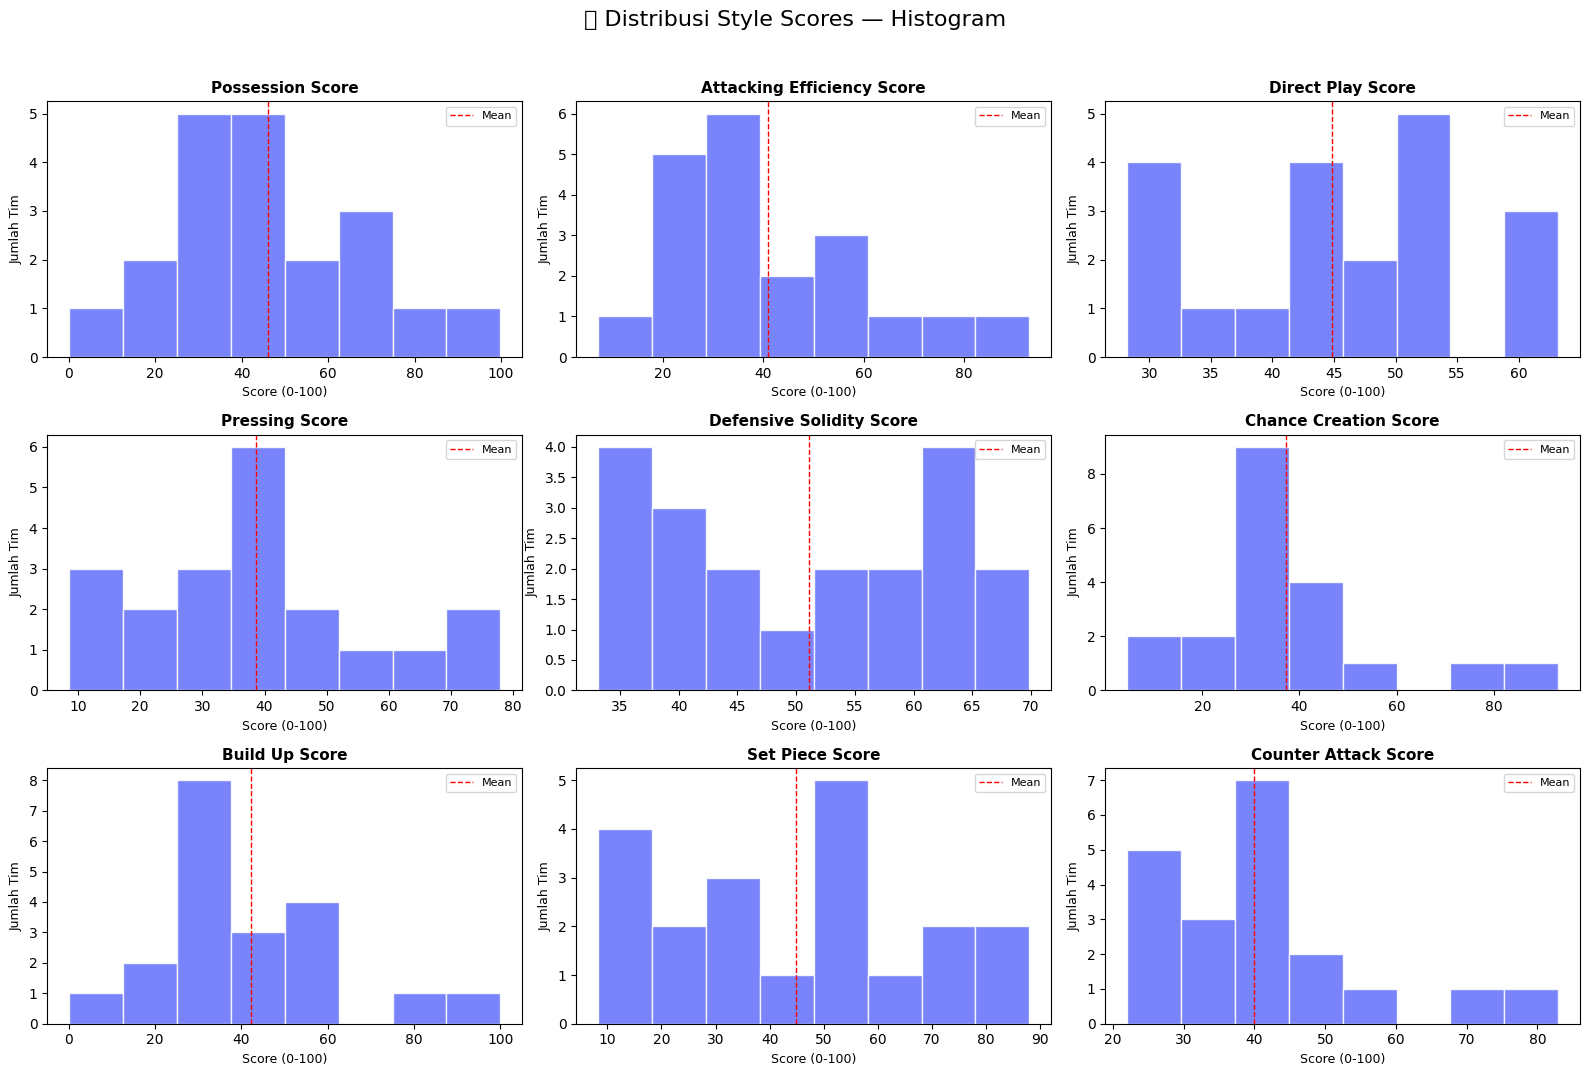

In [320]:
# --- Histogram untuk setiap style score ---
n_scores = len(score_cols)
n_cols_grid = 3
n_rows_grid = (n_scores + n_cols_grid - 1) // n_cols_grid

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(16, n_rows_grid * 3.5))
fig.suptitle("📊 Distribusi Style Scores — Histogram", fontsize=16, y=1.02)

for idx, col in enumerate(score_cols):
    ax = axes.flat[idx]
    ax.hist(teams_style_scores[col], bins=8, color="#636EFA", edgecolor="white", alpha=0.85)
    ax.set_title(col.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("Score (0-100)", fontsize=9)
    ax.set_ylabel("Jumlah Tim", fontsize=9)
    ax.axvline(teams_style_scores[col].mean(), color="red", linestyle="--", linewidth=1, label="Mean")
    ax.legend(fontsize=8)

# Sembunyikan axes kosong
for idx in range(n_scores, len(axes.flat)):
    axes.flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [321]:
# --- Boxplot untuk seluruh style scores ---
fig = px.box(
    teams_style_scores.melt(id_vars="club", value_vars=score_cols,
                            var_name="Style", value_name="Score"),
    x="Style",
    y="Score",
    color="Style",
    title="📦 Boxplot — Distribusi Style Scores",
    points="all",
    hover_data=["club"],
)

fig.update_layout(
    width=1100,
    height=500,
    showlegend=False,
    xaxis_tickangle=-25,
    xaxis_title="",
    yaxis_title="Score (0-100)",
)
fig.show()

### 8.2 Ranking — Horizontal Bar Chart

Ranking menampilkan **urutan tim dari skor tertinggi ke terendah** untuk setiap dimensi.  
Ini membantu memvalidasi bahwa scoring masuk akal secara sepakbola — misalnya Barcelona dan Real Madrid diharapkan tinggi di Possession Score.

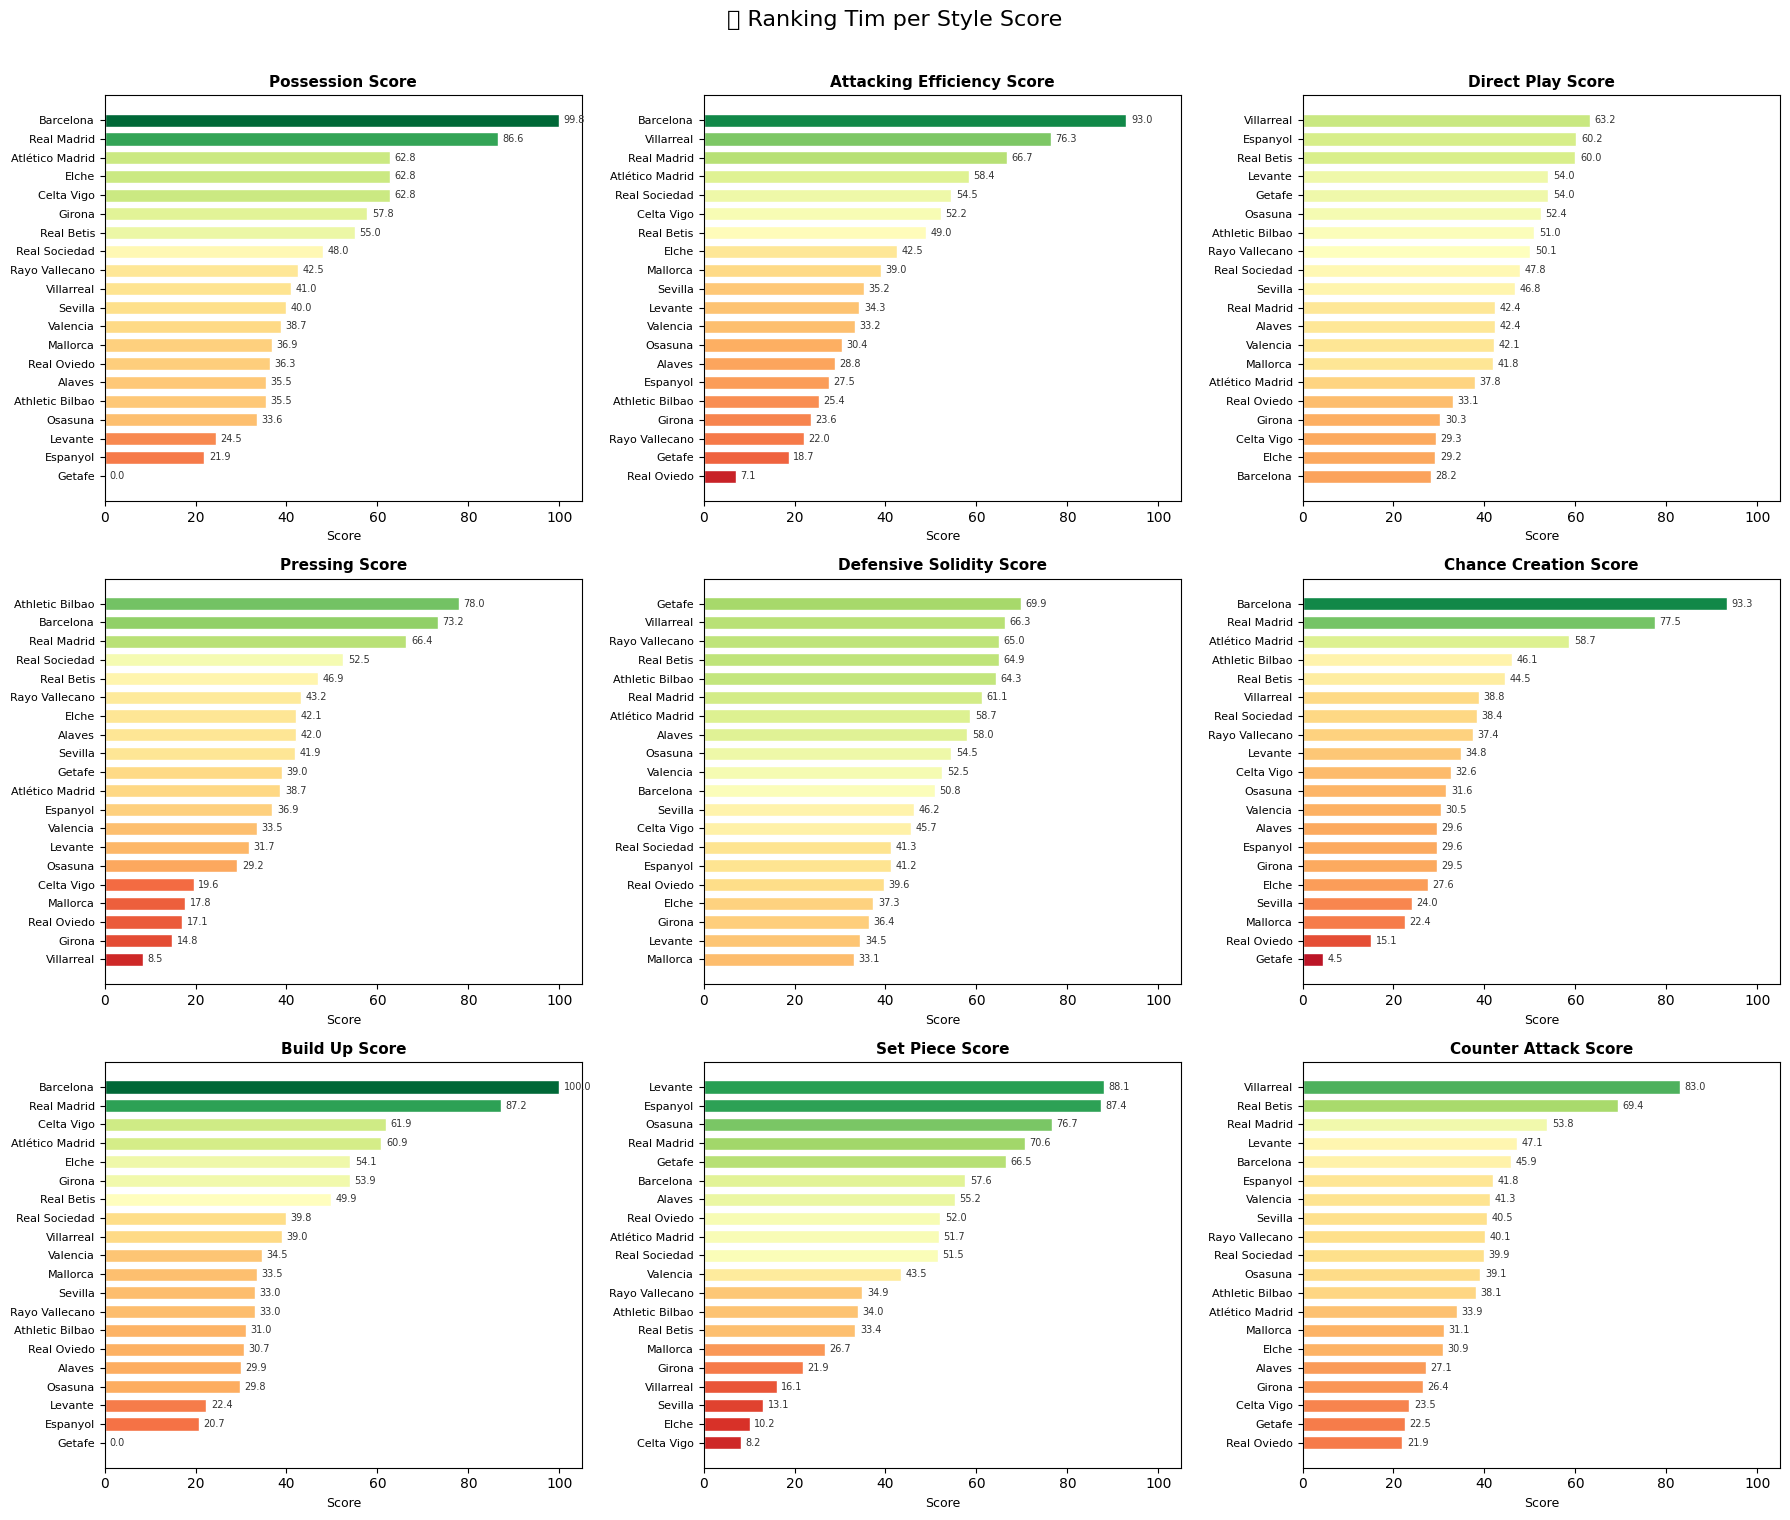

In [322]:
# --- Horizontal Bar Chart: Ranking per Style ---
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, n_rows_grid * 5))
fig.suptitle("🏆 Ranking Tim per Style Score", fontsize=16, y=1.01)

# Color palette: gradient dari rendah (merah) ke tinggi (biru)
cmap = plt.cm.RdYlGn

for idx, col in enumerate(score_cols):
    ax = axes.flat[idx]
    sorted_df = teams_style_scores[["club", col]].sort_values(col, ascending=True)

    # Normalisasi warna
    colors = cmap(sorted_df[col].values / 100)

    ax.barh(sorted_df["club"], sorted_df[col], color=colors, edgecolor="white", height=0.7)
    ax.set_title(col.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_xlim(0, 105)
    ax.set_xlabel("Score", fontsize=9)
    ax.tick_params(axis='y', labelsize=8)

    # Annotate skor di ujung bar
    for i, (val, club) in enumerate(zip(sorted_df[col], sorted_df["club"])):
        ax.text(val + 1, i, f"{val:.1f}", va="center", fontsize=7, color="#333")

# Sembunyikan axes kosong
for idx in range(n_scores, len(axes.flat)):
    axes.flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

### 8.3 Heatmap — Seluruh Style Scores

Heatmap ini memberikan gambaran **komparatif** seluruh 20 tim di 10 dimensi gaya bermain sekaligus.  
Warna **hijau** = skor tinggi, **merah** = skor rendah.


In [323]:
# --- Heatmap: Semua Style Scores ---
df_heatmap = teams_style_scores.set_index("club")[score_cols].sort_values(
    "possession_score", ascending=True
)

heatmap_labels = [c.replace("_score", "").replace("_", " ").title() + " Score" for c in score_cols]

fig = px.imshow(
    df_heatmap,
    text_auto=".1f",
    color_continuous_scale="RdYlGn",
    aspect="auto",
    title="🗺️ Heatmap — Style Scores Seluruh Tim LaLiga",
    labels={"x": "Style Dimension", "y": "Club", "color": "Score"},
)

fig.update_layout(
    width=1100,
    height=700,
    font=dict(size=11),
    title_font_size=16,
    xaxis_tickangle=-30,
)

fig.update_xaxes(ticktext=heatmap_labels, tickvals=list(range(len(heatmap_labels))))

fig.show()


### 8.3 Correlation Heatmap

Korelasi antar style scores membantu memahami **hubungan antar dimensi gaya bermain**:  
- **Korelasi positif tinggi** → Dua style cenderung muncul bersamaan (misal: Possession & Build-up).
- **Korelasi negatif** → Dua style cenderung bertolak belakang (misal: Possession vs Direct Play).
- **Korelasi rendah** → Dua style saling independen.

In [324]:
# --- Correlation Heatmap ---
corr = teams_style_scores[score_cols].corr()

# Buat label yang lebih pendek
short_labels = [c.replace("_score", "").replace("_", " ").title() for c in score_cols]

fig = px.imshow(
    corr,
    x=short_labels,
    y=short_labels,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="🔗 Correlation Heatmap — Style Scores",
    aspect="auto",
)

fig.update_layout(
    width=800,
    height=700,
    font=dict(size=10),
    title_font_size=16,
    xaxis_tickangle=-30,
)
fig.show()

In [325]:
# --- Interpretasi Korelasi: Pasangan Tertinggi & Terendah ---
# Ambil pasangan unik (segitiga atas matriks korelasi)
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["Style A", "Style B", "Correlation"]
corr_pairs = corr_pairs.sort_values("Correlation", ascending=False)

print("🔝 Top 5 Korelasi POSITIF Tertinggi:")
print("─" * 65)
for _, row in corr_pairs.head(5).iterrows():
    a = row["Style A"].replace("_score", "").replace("_", " ").title()
    b = row["Style B"].replace("_score", "").replace("_", " ").title()
    print(f"  {a:<30s} ↔ {b:<30s}  r = {row['Correlation']:+.3f}")

print()
print("🔻 Top 5 Korelasi NEGATIF Terendah:")
print("─" * 65)
for _, row in corr_pairs.tail(5).iterrows():
    a = row["Style A"].replace("_score", "").replace("_", " ").title()
    b = row["Style B"].replace("_score", "").replace("_", " ").title()
    print(f"  {a:<30s} ↔ {b:<30s}  r = {row['Correlation']:+.3f}")

🔝 Top 5 Korelasi POSITIF Tertinggi:
─────────────────────────────────────────────────────────────────
  Possession                     ↔ Build Up                        r = +0.992
  Chance Creation                ↔ Build Up                        r = +0.848
  Possession                     ↔ Chance Creation                 r = +0.823
  Attacking Efficiency           ↔ Chance Creation                 r = +0.781
  Attacking Efficiency           ↔ Build Up                        r = +0.759

🔻 Top 5 Korelasi NEGATIF Terendah:
─────────────────────────────────────────────────────────────────
  Counter Attack                 ↔ Defensive Solidity              r = +nan
  Counter Attack                 ↔ Chance Creation                 r = +nan
  Counter Attack                 ↔ Build Up                        r = +nan
  Counter Attack                 ↔ Set Piece                       r = +nan
  Counter Attack                 ↔ Counter Attack                  r = +nan


### 8.4 Radar Chart — Profil Gaya Bermain

Radar chart menampilkan **profil multidimensi** gaya bermain sebuah tim secara visual.  
Setiap sumbu mewakili satu style score. Tim dengan area radar yang luas menunjukkan keunggulan di banyak aspek, sedangkan tonjolan di sisi tertentu menunjukkan spesialisasi.

In [326]:
# ===========================================================================
# Fungsi Radar Chart
# ===========================================================================

def radar_chart(
    df: pd.DataFrame,
    clubs: list[str],
    score_columns: list[str],
    colors: list[str] | None = None,
    title: str = "Radar Chart",
) -> go.Figure:
    """Buat radar chart perbandingan untuk satu atau beberapa klub.

    Args:
        df: DataFrame berisi kolom 'club' dan kolom-kolom skor.
        clubs: List nama klub.
        score_columns: List kolom skor.
        colors: List warna untuk setiap klub.
        title: Judul chart.

    Returns:
        Plotly Figure.
    """
    if colors is None:
        colors = px.colors.qualitative.Plotly[:len(clubs)]

    labels = [c.replace("_score", "").replace("_", " ").title() for c in score_columns]
    labels_closed = labels + [labels[0]]  # Tutup lingkaran

    fig = go.Figure()
    for club, color in zip(clubs, colors):
        row = df[df["club"] == club].iloc[0]
        values = [row[col] for col in score_columns] + [row[score_columns[0]]]
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=labels_closed,
            fill="toself",
            opacity=0.2,
            line=dict(color=color, width=2.5),
            name=club,
        ))

    fig.update_layout(
        polar=dict(
            radialaxis=dict(visible=True, range=[0, 100], ticksuffix=""),
        ),
        title=dict(text=title, font=dict(size=16)),
        width=700,
        height=550,
        legend=dict(font=dict(size=12)),
    )

    return fig


print("✅ Fungsi radar_chart() siap.")

✅ Fungsi radar_chart() siap.


In [327]:
# --- Radar Chart: Barcelona ---
radar_chart(
    teams_style_scores,
    clubs=["Barcelona"],
    score_columns=score_cols,
    colors=["#A50044"],
    title="🕸️ Barcelona — Style Profile",
).show()

In [328]:
# --- Radar Chart: Real Madrid ---
radar_chart(
    teams_style_scores,
    clubs=["Real Madrid"],
    score_columns=score_cols,
    colors=["#FEBE10"],
    title="🕸️ Real Madrid — Style Profile",
).show()

In [329]:
# --- Radar Chart: Atlético Madrid ---
radar_chart(
    teams_style_scores,
    clubs=["Atlético Madrid"],
    score_columns=score_cols,
    colors=["#CE3524"],
    title="🕸️ Atlético Madrid — Style Profile",
).show()

In [330]:
# --- Radar Comparison: 5 klub representatif ---
radar_chart(
    teams_style_scores,
    clubs=["Barcelona", "Real Madrid", "Atlético Madrid", "Getafe", "Mallorca"],
    score_columns=score_cols,
    colors=["#A50044", "#FEBE10", "#CE3524", "#005999", "#8B0000"],
    title="🕸️ Perbandingan 5 Klub — Style Profile",
).show()

### 8.5 PCA Visualization — Persebaran Klub dalam 2 Dimensi

**Principal Component Analysis (PCA)** digunakan untuk mereduksi 10 dimensi style score menjadi **2 dimensi** yang dapat divisualisasikan.  

Tujuan:
- Melihat **persebaran** dan **pengelompokan alami** klub berdasarkan style score.
- Mengidentifikasi klub-klub yang memiliki profil gaya bermain serupa (berdekatan) atau berbeda (berjauhan).

> ⚠️ **Catatan:** Pada tahap ini belum dilakukan clustering. Visualisasi PCA hanya bertujuan eksplorasi awal.

In [331]:
# --- PCA: Reduksi ke 2 Dimensi ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(teams_style_scores[score_cols])

df_pca = pd.DataFrame({
    "club": teams_style_scores["club"],
    "PC1": pca_result[:, 0],
    "PC2": pca_result[:, 1],
})

# Explained variance
ev1 = pca.explained_variance_ratio_[0] * 100
ev2 = pca.explained_variance_ratio_[1] * 100
print(f"📐 PCA Explained Variance:")
print(f"   PC1: {ev1:.1f}%")
print(f"   PC2: {ev2:.1f}%")
print(f"   Total: {ev1 + ev2:.1f}%")

📐 PCA Explained Variance:
   PC1: 52.9%
   PC2: 22.2%
   Total: 75.1%


In [332]:
# --- PCA Scatter Plot ---
fig = px.scatter(
    df_pca,
    x="PC1",
    y="PC2",
    text="club",
    title=f"📐 PCA — Persebaran Klub (PC1: {ev1:.1f}%, PC2: {ev2:.1f}%)",
    labels={"PC1": f"PC1 ({ev1:.1f}%)", "PC2": f"PC2 ({ev2:.1f}%)"},
)

fig.update_traces(
    textposition="top center",
    marker=dict(size=10, color="#636EFA"),
    textfont=dict(size=10),
)

fig.update_layout(
    width=900,
    height=650,
    font=dict(size=12),
)
fig.show()

In [333]:
# --- PCA Loading: kontribusi setiap style terhadap PC1 & PC2 ---
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=score_cols,
)

print("📊 PCA Loadings (kontribusi setiap style):")
print(loadings.round(3))

📊 PCA Loadings (kontribusi setiap style):
                             PC1   PC2
possession_score            0.51 -0.14
attacking_efficiency_score  0.43  0.03
direct_play_score          -0.10  0.19
pressing_score              0.22  0.35
defensive_solidity_score    0.03  0.12
chance_creation_score       0.44  0.24
build_up_score              0.53 -0.10
set_piece_score            -0.09  0.85
counter_attack_score        0.13  0.11


---

## 9. Output Dataset — Simpan ke CSV

Dataset final `teams_style_scores` berisi **club + 10 style scores** (skala 0–100).  
File ini akan menjadi input langsung untuk notebook **K-Means Clustering** berikutnya.

In [334]:
# --- Preview Dataset Final ---
print("📦 Dataset Final: teams_style_scores")
print("=" * 60)
print(f"   Shape  : {teams_style_scores.shape}")
print(f"   Kolom  : {list(teams_style_scores.columns)}")
print(f"   Range  : {teams_style_scores[score_cols].min().min():.2f} – {teams_style_scores[score_cols].max().max():.2f}")
print()
teams_style_scores.sort_values("club").reset_index(drop=True)

📦 Dataset Final: teams_style_scores
   Shape  : (20, 10)
   Kolom  : ['club', 'possession_score', 'attacking_efficiency_score', 'direct_play_score', 'pressing_score', 'defensive_solidity_score', 'chance_creation_score', 'build_up_score', 'set_piece_score', 'counter_attack_score']
   Range  : 0.00 – 100.00



,club,possession_score,attacking_efficiency_score,direct_play_score,pressing_score,defensive_solidity_score,chance_creation_score,build_up_score,set_piece_score,counter_attack_score
0,Alaves,35.54,28.84,42.39,42.00,58.01,29.60,29.93,55.21,27.11
1,Athletic Bilbao,35.48,25.37,50.96,77.96,64.27,46.15,31.02,34.02,38.08
2,Atlético Madrid,62.80,58.39,37.83,38.66,58.67,58.67,60.86,51.70,33.93
3,Barcelona,99.85,92.97,28.16,73.25,50.82,93.29,100.00,57.58,45.88
4,Celta Vigo,62.75,52.20,29.33,19.63,45.68,32.58,61.90,8.21,23.52
5,Elche,62.78,42.47,29.21,42.06,37.34,27.62,54.07,10.18,30.88
6,Espanyol,21.93,27.52,60.25,36.89,41.25,29.59,20.71,87.36,41.80
7,Getafe,0.00,18.70,54.03,38.98,69.87,4.45,0.00,66.52,22.48
8,Girona,57.78,23.62,30.34,14.81,36.43,29.47,53.87,21.89,26.44
9,Levante,24.50,34.26,54.05,31.70,34.47,34.77,22.35,88.06,47.15


In [335]:
# --- Simpan ke CSV ---
output_dir = PROJECT_ROOT / "data" / "ml_ready"
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "teams_style_scores.csv"
teams_style_scores.sort_values("club").to_csv(output_path, index=False)

print(f"✅ Dataset disimpan ke: {output_path}")
print(f"   Size: {output_path.stat().st_size / 1024:.1f} KB")

✅ Dataset disimpan ke: /Users/g/Desktop/Documents/LaLiga/laliga-project/data/ml_ready/teams_style_scores.csv
   Size: 1.4 KB


---

## ✅ Kesimpulan

Notebook ini telah berhasil membangun **10 Style Scores** yang merepresentasikan dimensi taktis gaya bermain 20 tim La Liga.

### Metodologi
1. **Data Source** — Tabel `gold.teams_statistics` (One Big Table hasil ETL).
2. **Normalisasi** — Min-Max Scaling ke skala 0–100, dengan inverse scaling untuk indikator negatif.
3. **Weighted Average** — Primary (70%) + Supporting (30%), bobot dibagi rata per indikator.

### Hasil

| Style Score | Deskripsi |
|---|---|
| `possession_score` | Dominasi penguasaan bola |
| `build_up_score` | Kemampuan membangun serangan bertahap |
| `chance_creation_score` | Kemampuan menciptakan peluang |
| `attacking_efficiency_score` | Efektivitas konversi peluang → gol |
| `direct_play_score` | Kecenderungan bermain cepat & vertikal |
| `counter_attack_score` | Efektivitas serangan balik |
| `pressing_score` | Intensitas tekanan terhadap lawan |
| `defensive_solidity_score` | Kualitas pertahanan |
| `set_piece_score` | Ancaman dari bola mati |
| `discipline_score` | Kedisiplinan & minimnya kesalahan |

### Output
- File: `data/ml_ready/teams_style_scores.csv`
- Shape: 20 baris (klub) × 11 kolom (club + 10 style scores)

### Next Step
→ **Notebook berikutnya:** K-Means Clustering — mengelompokkan tim berdasarkan style scores untuk mengidentifikasi pola gaya bermain di La Liga.